# OIBSIP Data Analytics — Task 1: EDA on Retail Sales Data

**Objective:** Explore retail sales to identify time trends, customer behaviour, product/category performance and business opportunities.

**Source:** Uploaded *Indian FMCG Retail Sales & Customer Inventory (2024)* dataset. Because the source does not contain a literal product-name column, `Brand + Category` is used as a transparent **Product Proxy** for the required product-level ranking.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

DATA=Path('../data/retail_sales_fmcg_2024.csv')
df=pd.read_csv(DATA, parse_dates=['Invoice_Date'])
print('Shape:', df.shape)
display(df.head())
print('\nDtypes:')
display(df.dtypes.to_frame('dtype'))
print('\nNull values:')
display(df.isna().sum().to_frame('null_count'))

Shape: (100000, 22)


,Invoice_ID,Invoice_Date,City,Store_Format,Category,Brand,Channel,Payment_Mode,Units,Cost_Price,Selling_Price,Revenue,Cost,Margin,Margin_%,Stock_On_Hand,Reorder_Level,Lead_Time_Days,Customer_Age,Customer_Gender,Loyalty_Flag,Product_Proxy
0,58018430,2024-02-02 13:50:00,Kolkata,Super,Grocery,Nestle,Online,Wallet,2,148.999035,175.057209,350.114418,297.998070,52.116348,0.148855,154,31,11,20.0,M,1,Nestle - Grocery
1,48157952,2024-10-09 11:52:00,Hyderabad,Hyper,Home Care,PepsiCo,Offline,Wallet,1,80.626759,106.034197,106.034197,80.626759,25.407438,0.239616,130,24,5,26.0,F,1,PepsiCo - Home Care
2,23283831,2024-08-26 22:03:00,Chennai,Hyper,Snacks,PepsiCo,Online,Card,5,181.233170,208.980023,1044.900114,906.165848,138.734266,0.132773,270,44,8,27.0,F,0,PepsiCo - Snacks
3,53537460,2024-06-09 04:34:00,Bengaluru,Hyper,Beverages,Nestle,Omnichannel,Card,2,195.811402,260.879960,521.759920,391.622805,130.137115,0.249420,403,63,8,NaN,F,0,Nestle - Beverages
4,55348596,2024-06-07 01:13:00,Delhi,Super,Snacks,ITC,Offline,Card,3,23.571888,30.624472,91.873416,70.715665,21.157751,0.230292,366,40,9,60.0,F,1,ITC - Snacks



Dtypes:


,dtype
Invoice_ID,int64
Invoice_Date,datetime64[ns]
City,object
Store_Format,object
Category,object
Brand,object
Channel,object
Payment_Mode,object
Units,int64
Cost_Price,float64



Null values:


,null_count
Invoice_ID,0
Invoice_Date,0
City,0
Store_Format,0
Category,0
Brand,0
Channel,0
Payment_Mode,0
Units,0
Cost_Price,0


## Initial inspection — observation
The dataset contains transaction-level FMCG sales, customer demographics, pricing, margin, inventory and channel information. Missing values are concentrated in customer age/gender fields, so demographic charts should explicitly account for missing observations.

In [2]:
num=df.select_dtypes(include=np.number).columns
stats=pd.DataFrame({'mean':df[num].mean(),'median':df[num].median(),'mode':df[num].mode().iloc[0],'std':df[num].std()})
display(stats)

,mean,median,mode,std
Invoice_ID,5.512347e+07,5.518370e+07,1.062645e+07,2.596457e+07
Units,2.998290e+00,3.000000e+00,3.000000e+00,1.414619e+00
Cost_Price,1.048596e+02,1.049037e+02,1.000053e+01,5.482534e+01
Selling_Price,1.311074e+02,1.299992e+02,1.058091e+01,6.986238e+01
Revenue,3.933513e+02,3.133491e+02,1.065320e+01,2.971547e+02
Cost,3.146145e+02,2.528019e+02,1.000202e+01,2.349020e+02
Margin,7.873686e+01,5.355272e+01,5.568705e-01,7.423635e+01
Margin_%,1.933680e-01,2.002868e-01,4.762128e-02,7.514318e-02
Stock_On_Hand,2.741567e+02,2.740000e+02,4.520000e+02,1.298539e+02
Reorder_Level,4.946771e+01,5.000000e+01,5.600000e+01,1.730561e+01


## Descriptive statistics — observation
Mean, median, mode and standard deviation are calculated for every numerical column, as required. Large mean/median differences highlight variables with skew or operational extremes that deserve attention during interpretation.

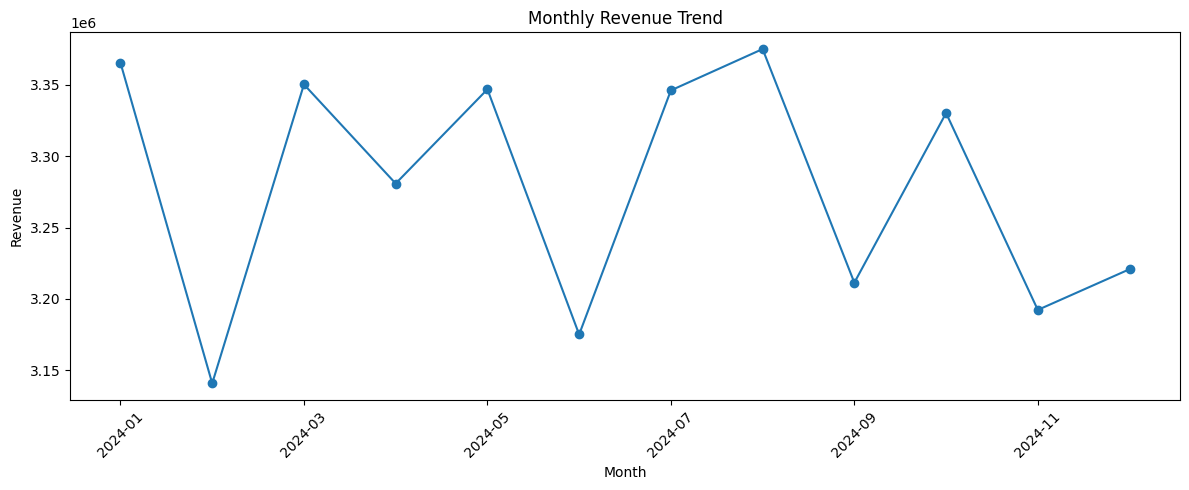

In [3]:
df['Month']=df.Invoice_Date.dt.to_period('M').astype(str)
df['Quarter']=df.Invoice_Date.dt.to_period('Q').astype(str)
monthly=df.groupby('Month')['Revenue'].sum()
quarterly=df.groupby('Quarter')['Revenue'].sum()
plt.figure(figsize=(12,5)); monthly.plot(marker='o'); plt.title('Monthly Revenue Trend'); plt.xlabel('Month'); plt.ylabel('Revenue'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

**Observation:** Monthly revenue shows the year’s demand pattern. Peaks and dips can be used for inventory planning and promotional timing.

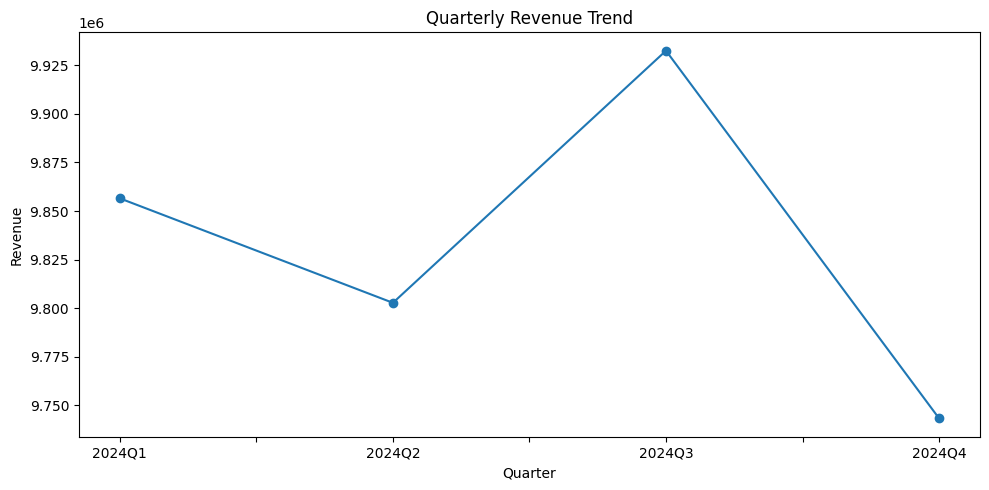

In [4]:
plt.figure(figsize=(10,5)); quarterly.plot(kind='line',marker='o'); plt.title('Quarterly Revenue Trend'); plt.xlabel('Quarter'); plt.ylabel('Revenue'); plt.tight_layout(); plt.show()

**Observation:** Quarterly aggregation smooths monthly noise and provides a higher-level view of performance across the year.

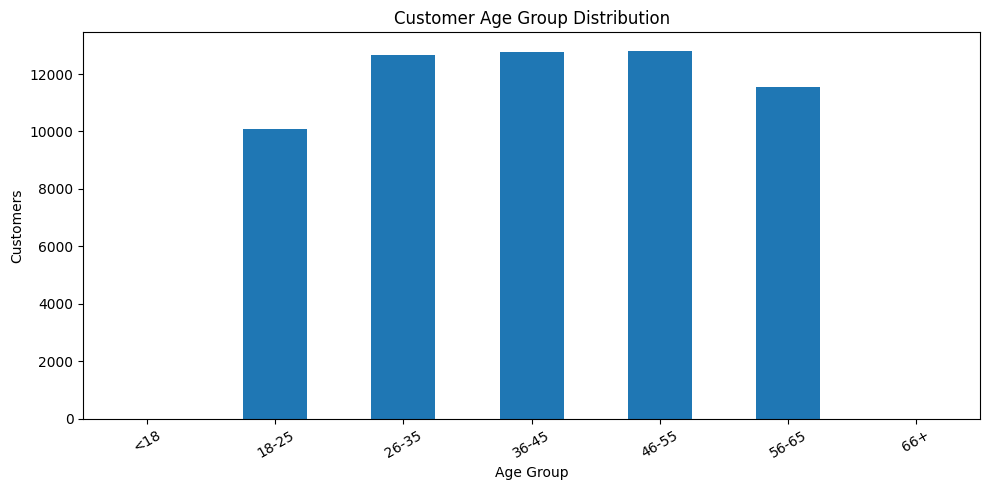

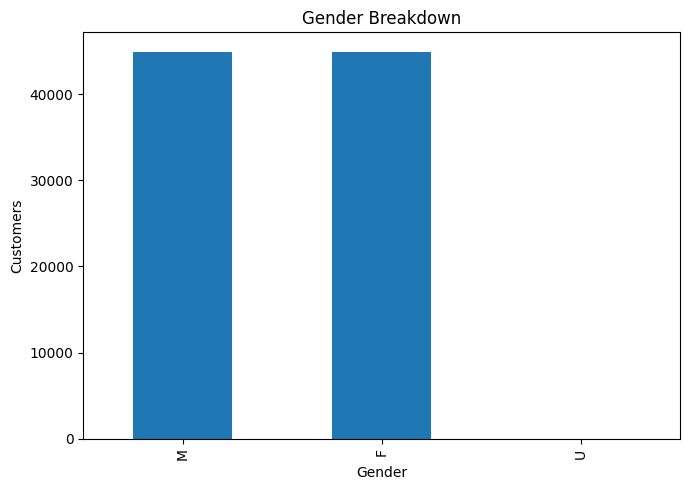

In [5]:
bins=[0,17,25,35,45,55,65,120]; labels=['<18','18-25','26-35','36-45','46-55','56-65','66+']
df['Age_Group']=pd.cut(df.Customer_Age,bins=bins,labels=labels)
plt.figure(figsize=(10,5)); df['Age_Group'].value_counts().reindex(labels).plot(kind='bar'); plt.title('Customer Age Group Distribution'); plt.xlabel('Age Group'); plt.ylabel('Customers'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()
plt.figure(figsize=(7,5)); df['Customer_Gender'].value_counts().reindex(['M','F','U']).plot(kind='bar'); plt.title('Gender Breakdown'); plt.xlabel('Gender'); plt.ylabel('Customers'); plt.tight_layout(); plt.show()

**Observation:** Age and gender distributions should be interpreted alongside the missing-value count. Demographic targeting is most reliable for groups with sufficient non-null records.

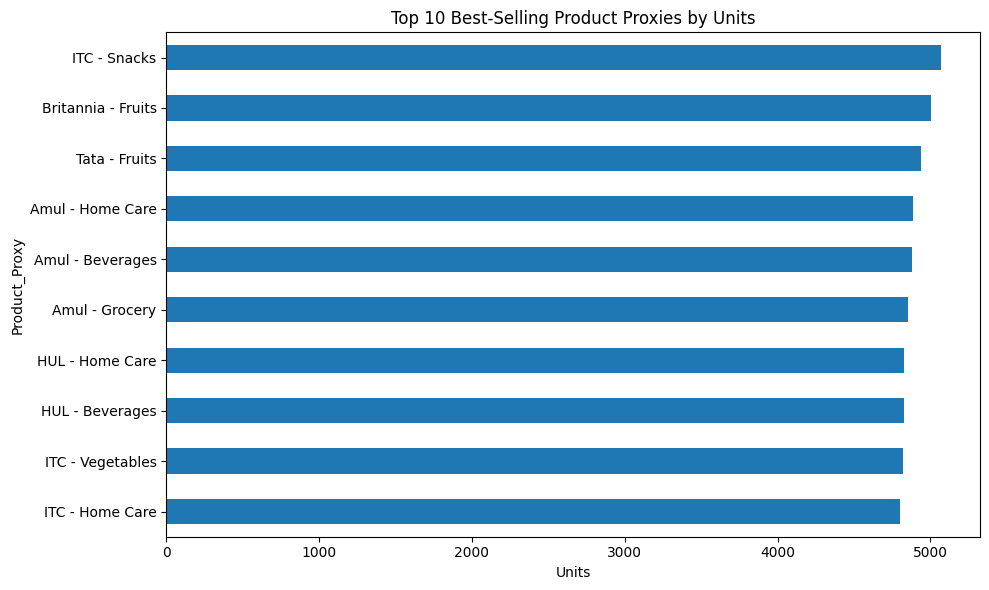

In [6]:
top10=df.groupby('Product_Proxy')['Units'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6)); top10.sort_values().plot(kind='barh'); plt.title('Top 10 Best-Selling Product Proxies by Units'); plt.xlabel('Units'); plt.tight_layout(); plt.show()

**Observation:** The top product proxies represent the highest-volume Brand–Category combinations and are candidates for stronger replenishment and merchandising focus.

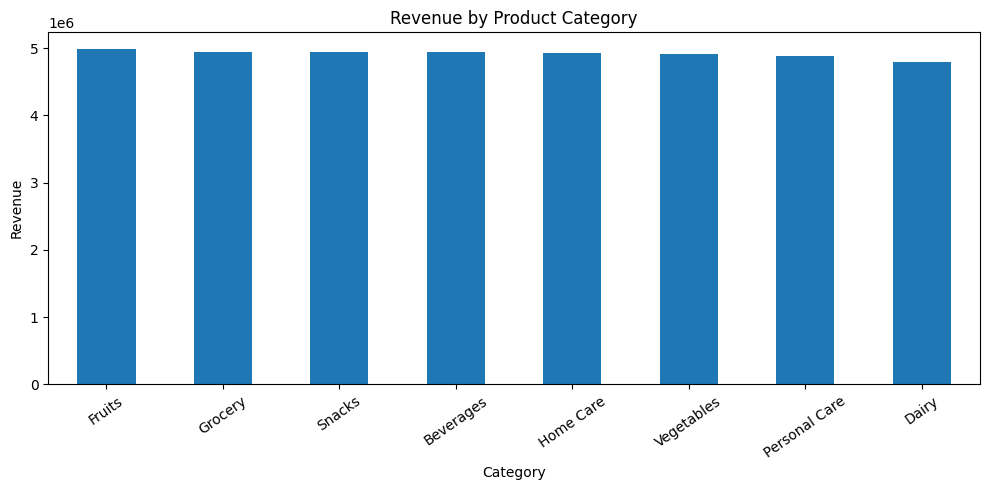

In [7]:
cat=df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5)); cat.plot(kind='bar'); plt.title('Revenue by Product Category'); plt.ylabel('Revenue'); plt.xticks(rotation=35); plt.tight_layout(); plt.show()

**Observation:** Category revenue identifies where commercial attention has the greatest financial impact; category-level campaigns and assortment decisions should prioritize the strongest contributors while investigating weak categories.

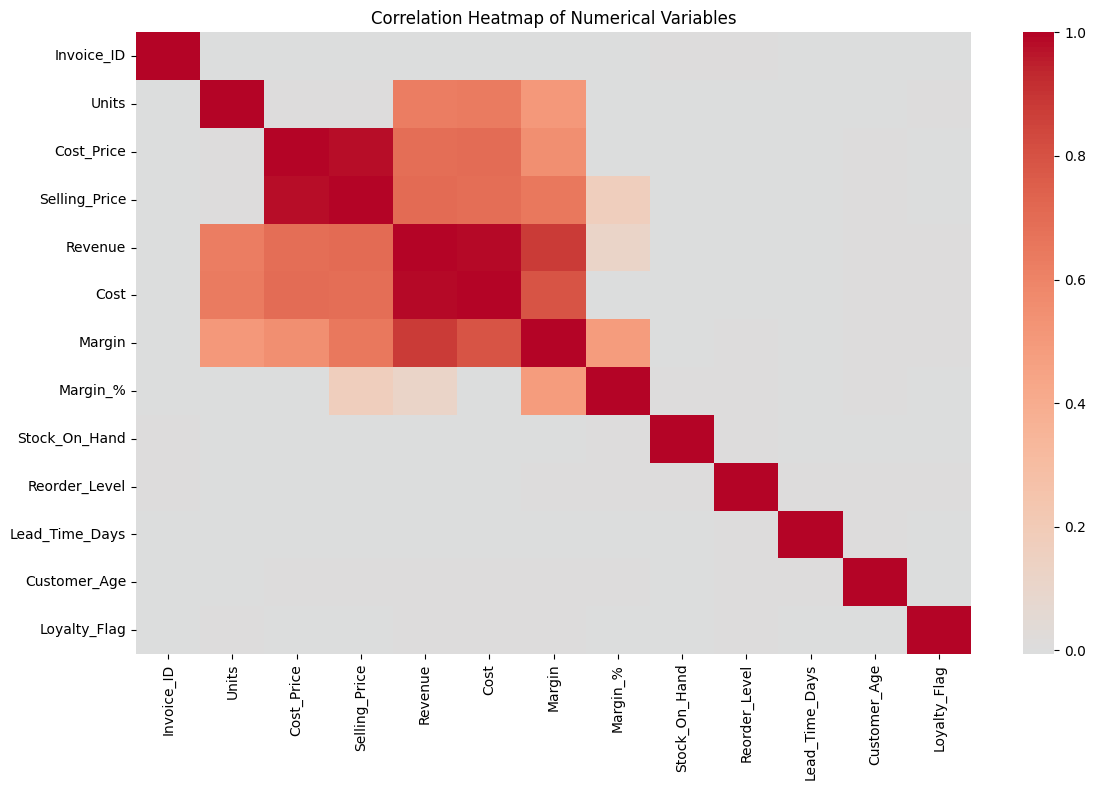

In [8]:
corr=df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12,8)); sns.heatmap(corr,cmap='coolwarm',center=0); plt.title('Correlation Heatmap of Numerical Variables'); plt.tight_layout(); plt.show()

**Observation:** The heatmap highlights relationships among units, pricing, revenue, margin and inventory variables. Strong mathematical relationships involving revenue are expected because revenue is constructed from transaction quantities and prices.

/tmp/ipykernel_1093/168357570.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rev=df.dropna(subset=['Age_Group']).groupby('Age_Group')['Revenue'].mean()


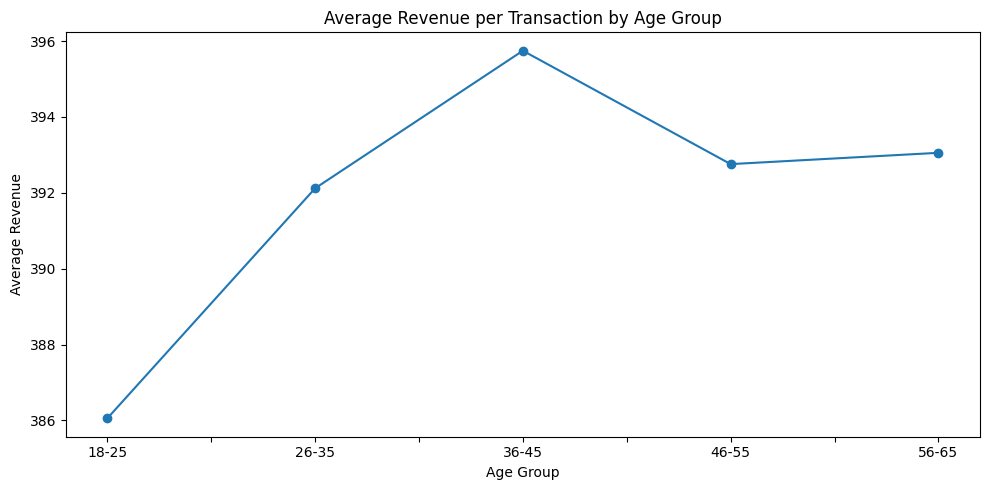

In [9]:
age_rev=df.dropna(subset=['Age_Group']).groupby('Age_Group')['Revenue'].mean()
plt.figure(figsize=(10,5)); age_rev.plot(kind='line',marker='o'); plt.title('Average Revenue per Transaction by Age Group'); plt.ylabel('Average Revenue'); plt.xlabel('Age Group'); plt.tight_layout(); plt.show()

**Observation:** This additional view tests whether transaction value differs across age groups, which can reveal customer segments that are more valuable per transaction even when their transaction counts are similar.

## Conclusion — actionable recommendations
1. **Plan inventory and promotions around the strongest monthly/quarterly periods**, using the time-series pattern to reduce stock-outs and excess inventory.
2. **Prioritize high-volume Brand–Category combinations and high-revenue categories** for replenishment, merchandising visibility and targeted campaigns.
3. **Use demographic and channel patterns carefully**: build age/gender campaigns only after accounting for missing demographics, and compare performance by channel before shifting marketing spend.

In [10]:
print('Dataset revenue total:', round(df.Revenue.sum(),2))
print('Units sold:', int(df.Units.sum()))
print('Overall margin %:', round(df.Margin.sum()/df.Revenue.sum()*100,2))

Dataset revenue total: 39335134.98
Units sold: 299829
Overall margin %: 20.02
